In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
import re

plt.rcParams['svg.fonttype'] = 'none'

In [2]:
df = pd.read_csv('../Data/CRX_Abundance.csv')

df.rename(columns={'sample name': 'mutation'}, inplace=True)

dfACT = pd.read_csv('../Data/DMSactivities.csv')

df = df.merge(dfACT, on='mutation', how='left')

In [3]:
wt_val = df.loc[df['mutation'] == 'CRX WT', 'relative expression level'].iloc[0]
df['abundance_delta'] = df['relative expression level'] - wt_val
df['abundance_log2fc'] = np.log2(df['relative expression level'] / wt_val)

df['activity_log2fc'] = np.log2(df['normalized_activity_score_mean'])

# Error propagation: if y = log2(x), then σ_y = σ_x / (x · ln2)
df['activity_log2fc_std'] = df['normalized_activity_score_std'] / (
    df['normalized_activity_score_mean'] * np.log(2)
)

/Users/trev/anaconda3/envs/analysis/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


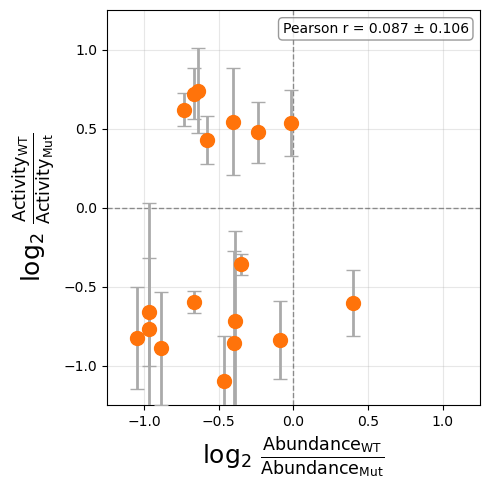

In [32]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.errorbar(
    df['abundance_log2fc'],
    df['activity_log2fc'],
    yerr=df['activity_log2fc_std'],
    fmt='o', markersize=10, color='#FF730A',
    ecolor='#aaaaaa', elinewidth=2, capsize=5,
    alpha=1, linewidth=1, zorder=3
)

ax.axhline(y=0.0, color='black', linestyle='--', linewidth=1, alpha=0.4)
ax.axvline(x=0.0, color='black', linestyle='--', linewidth=1, alpha=0.4)

ax.set_xlim(-1.25, 1.25)
ax.set_ylim(-1.25, 1.25)

ax.set_xlabel(r'log$_2$ $\frac{\mathrm{Abundance_{WT}}}{\mathrm{Abundance_{Mut}}}$', fontsize=18)
ax.set_ylabel(r'log$_2$ $\frac{\mathrm{Activity_{WT}}}{\mathrm{Activity_{Mut}}}$', fontsize=18)
ax.grid(alpha=0.3)

n_iterations = 1000
pearson_values = []

valid = df[['abundance_log2fc', 'activity_log2fc', 'activity_log2fc_std']].dropna()

for _ in range(n_iterations):
    sampled_y = [
        np.random.normal(row['activity_log2fc'], row['activity_log2fc_std'])
        for _, row in valid.iterrows()
    ]
    r_sample, _ = sp_stats.pearsonr(valid['abundance_log2fc'].values, sampled_y)
    pearson_values.append(r_sample)

pearson_r_mean = np.mean(pearson_values)
pearson_r_std  = np.std(pearson_values)

ax.text(0.97, 0.97,
        f'Pearson r = {pearson_r_mean:.3f} ± {pearson_r_std:.3f}',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=10, bbox=dict(boxstyle='round,pad=0.3',
                               facecolor='white', edgecolor='grey', alpha=0.8))

plt.tight_layout()
plt.savefig('/Users/trev/Downloads/abundance.svg')
plt.show()